In [ ]:
import pandas as pd

df = pd.read_csv("2) Stock Prices Data Set.csv")

df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [ ]:
df.shape

(302156, 7)

In [ ]:
df.columns

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302156 entries, 0 to 302155
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  302156 non-null  object 
 1   date    302156 non-null  object 
 2   open    302147 non-null  float64
 3   high    302150 non-null  float64
 4   low     302150 non-null  float64
 5   close   302156 non-null  float64
 6   volume  302156 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 16.1+ MB


In [ ]:
df.isnull().sum()

,0
symbol,0
date,0
open,9
high,6
low,6
close,0
volume,0


In [ ]:
df["date"] = pd.to_datetime(df["date"])

In [ ]:
df["date"].dtype

dtype('<M8[ns]')

In [ ]:
aapl = df[df["symbol"] == "AAPL"].copy()

In [ ]:
aapl = aapl.sort_values("date")

In [ ]:
aapl.head()

,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


In [ ]:
aapl.shape

(617, 7)

In [ ]:
aapl.set_index("date", inplace=True)

In [ ]:
aapl.head()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685


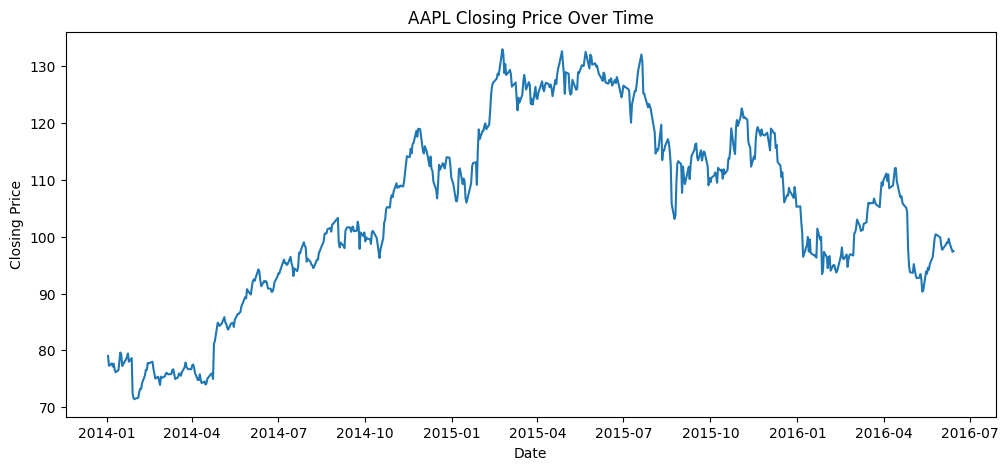

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(aapl.index, aapl["close"])

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("AAPL Closing Price Over Time")

plt.show()

In [ ]:
aapl["MA_30"] = aapl["close"].rolling(window=30).mean()

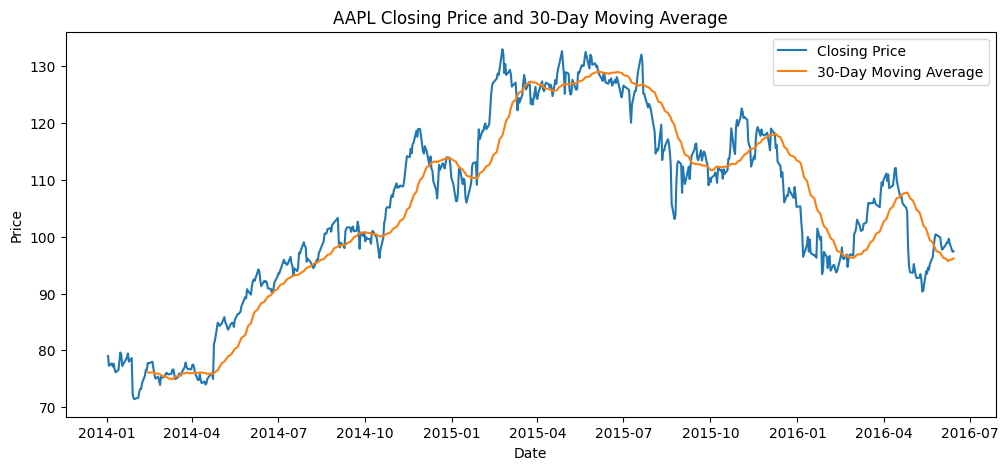

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(aapl.index, aapl["close"], label="Closing Price")
plt.plot(aapl.index, aapl["MA_30"], label="30-Day Moving Average")

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("AAPL Closing Price and 30-Day Moving Average")
plt.legend()

plt.show()

In [ ]:
monthly_price = aapl["close"].resample("ME").mean()

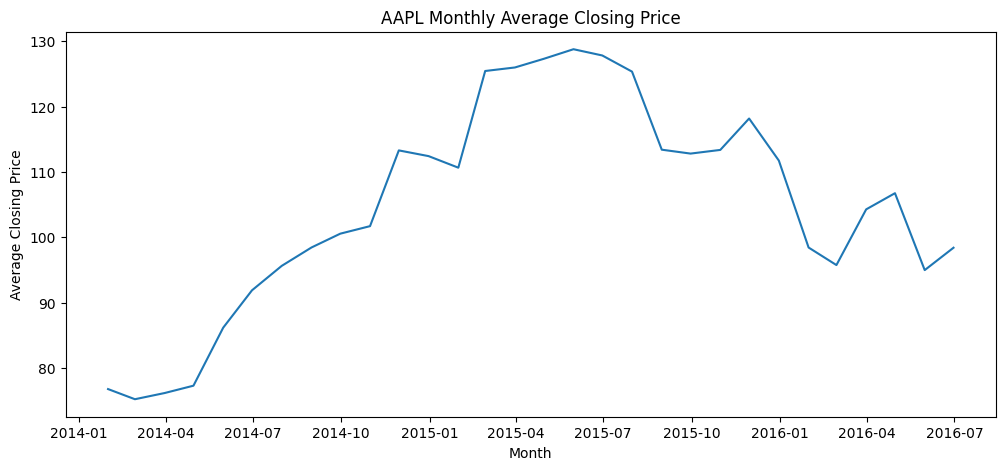

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_price.index, monthly_price.values)

plt.xlabel("Month")
plt.ylabel("Average Closing Price")
plt.title("AAPL Monthly Average Closing Price")

plt.show()

In [ ]:
monthly_price = aapl["close"].resample("M").mean()

/tmp/ipykernel_819/2476593143.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_price = aapl["close"].resample("M").mean()


The date column was converted into datetime format, the observations were sorted chronologically, daily closing prices were examined, a 30-day moving average was computed, and prices were aggregated to monthly averages in order to conduct the time series analysis of AAPL stock prices. The research reveals a general rising trend in the price of AAPL over the time period, interspersed with short-term swings and volatile times.